In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import reload

import simulate_data as sim
reload(sim)

import mfvb
reload(mfvb)
from mfvb import q_tobit

import evaluation as ev
reload(ev)

import gibbs 
reload(gibbs)
from gibbs import gibbs_disc_spike_slab

### Simulate data

Censored low: 200  |  uncensored: 600  |  Censored high: 200


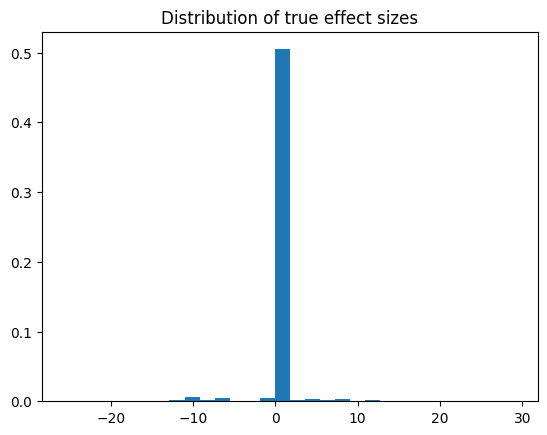

117.77591709054394

In [54]:
rng= np.random.default_rng(42)

n, d = 1_000, 500
l_perc, u_perc = 20, 80
r2 = 0.3
snr = r2/(1-r2)
perc_sig = 0.1
beta_scale = 10

X = sim.X_corr_blocks(n, d, k = 10, corr =0.7, seed = 42, intercept = False)
beta_true = sim.beta_sparse(d, beta_scale, perc_sig, seed = 42)
y, l, u, sigma_y_true, snr= sim.y_tobit_2(X, l_perc, u_perc, beta_true, snr = snr, seed=42)

mask_l   = (y == l)
mask_u   = (y == u)
mask_mid = ~mask_l & ~mask_u

print(f"Censored low: {mask_l.sum()}  |  uncensored: {mask_mid.sum()}  |  Censored high: {mask_u.sum()}")

plt.hist(beta_true, bins =30, density = True)
plt.title("Distribution of true effect sizes")
plt.show()

sigma_y_true

### Inference

In [58]:
import time

start = time.time()

model_vi = q_tobit(
    X, y,
    tau2=100.0,
    pi0=0.1, 
    seed=42,
)
model_vi.fit(n_iter=1000, em_warmup = 50, gamma_seq=False)

end = time.time()

print(f"VI training time: {end - start:.3f} s")


start = time.time()
model_gibbs = gibbs_disc_spike_slab(
    X, y,
    tau2=100.0,
    pi0=0.1,
    seed=42,
)
beta_samples, gamma_samples, sigma_samples = model_gibbs.fit(
    n_iter = 1500, 
    em_warmup = 0,
    burn_in = 500, 
    gamma_seq = False,
    em = True
)
end = time.time()

print(f"Gibbs training time: {end - start:.3f} s")

MFVI:   0%|          | 0/1050 [00:00<?, ?it/s]

Early stopping
VI training time: 7.487 s


Gibbs: 100%|██████████| 1500/1500 [01:40<00:00, 14.92it/s]

Gibbs training time: 100.554 s


In [59]:
print(model_vi.pi0, model_gibbs.pi0)
print(model_vi.tau2, model_gibbs.tau2)

0.01749345933251027 0.06174066305726911
475.0163993829318 169.68346399855156


### Evaluation

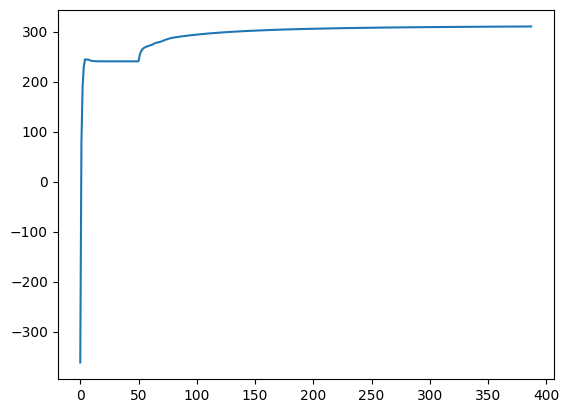

In [60]:
plt.plot(model_vi.elbo_history) 

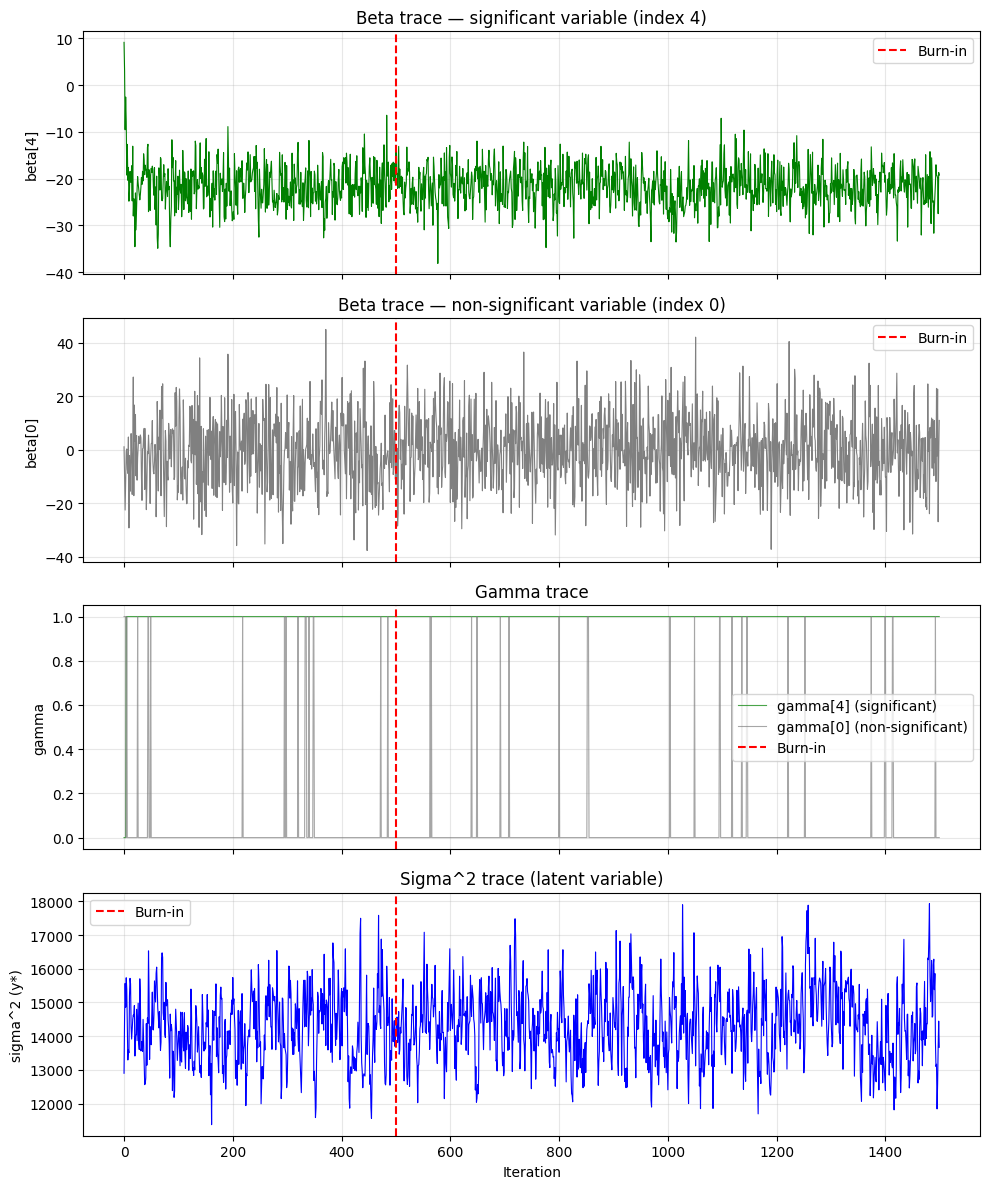

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Pick one "significant" (true signal) and one "non-significant" variable index
sig_true = np.asarray(sig_true).astype(bool)  # from earlier: beta_true != 0
idx_sig = np.where(sig_true)[0][0]        # first true-signal variable
idx_nonsig = np.where(~sig_true)[0][0]    # first null variable

beta_history = np.array(model_gibbs.beta_history)     # shape (n_iter, d)
gamma_history = np.array(model_gibbs.gamma_history)   # shape (n_iter, d)
sigma_history = np.array(model_gibbs.sigma_history)    # shape (n_iter,)

burn_in = 500  # use the same value as passed to fit()

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

# Beta - significant variable
axes[0].plot(beta_history[:, idx_sig], color="green", linewidth=0.8)
axes[0].axvline(burn_in, color="red", linestyle="--", label="Burn-in")
axes[0].set_ylabel(f"beta[{idx_sig}]")
axes[0].set_title(f"Beta trace — significant variable (index {idx_sig})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Beta - non-significant variable
axes[1].plot(beta_history[:, idx_nonsig], color="gray", linewidth=0.8)
axes[1].axvline(burn_in, color="red", linestyle="--", label="Burn-in")
axes[1].set_ylabel(f"beta[{idx_nonsig}]")
axes[1].set_title(f"Beta trace — non-significant variable (index {idx_nonsig})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gamma - both variables
axes[2].plot(gamma_history[:, idx_sig], color="green", linewidth=0.8, alpha=0.7,
             label=f"gamma[{idx_sig}] (significant)")
axes[2].plot(gamma_history[:, idx_nonsig], color="gray", linewidth=0.8, alpha=0.7,
             label=f"gamma[{idx_nonsig}] (non-significant)")
axes[2].axvline(burn_in, color="red", linestyle="--", label="Burn-in")
axes[2].set_ylabel("gamma")
axes[2].set_title("Gamma trace")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Sigma^2 of the latent variable
axes[3].plot(sigma_history, color="blue", linewidth=0.8)
axes[3].axvline(burn_in, color="red", linestyle="--", label="Burn-in")
axes[3].set_ylabel("sigma^2 (y*)")
axes[3].set_xlabel("Iteration")
axes[3].set_title("Sigma^2 trace (latent variable)")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

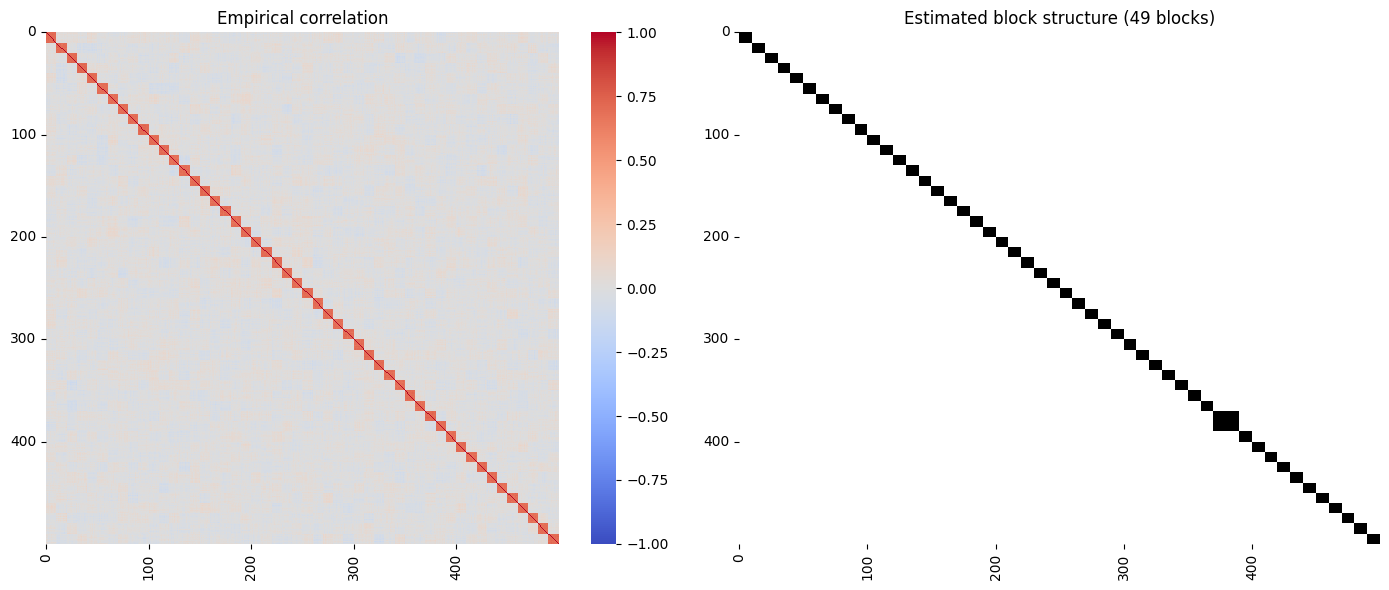

In [62]:
#correlation structure
block_ids, tol_used, corr = ev.compute_block_ids(X, alpha=0.01)

d = corr.shape[0]
ticks = np.arange(0, d, 100)

# Visualize the estimated block structure as a block-diagonal indicator matrix
block_matrix = (block_ids[:, None] == block_ids[None, :]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0], cbar=True)
axes[0].set_xticks(ticks)
axes[0].set_xticklabels(ticks)
axes[0].set_yticks(ticks)
axes[0].set_yticklabels(ticks)
axes[0].set_title("Empirical correlation")

sns.heatmap(block_matrix, cmap="Greys", vmin=0, vmax=1, ax=axes[1], cbar=False)
axes[1].set_xticks(ticks)
axes[1].set_xticklabels(ticks)
axes[1].set_yticks(ticks)
axes[1].set_yticklabels(ticks)
axes[1].set_title(f"Estimated block structure ({len(np.unique(block_ids))} blocks)")

plt.tight_layout()
plt.show()

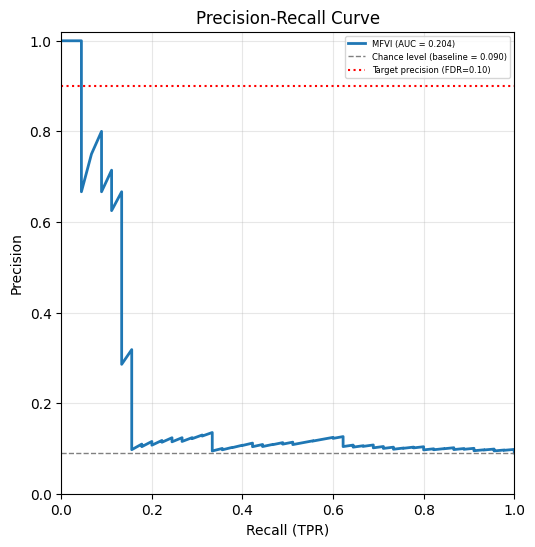

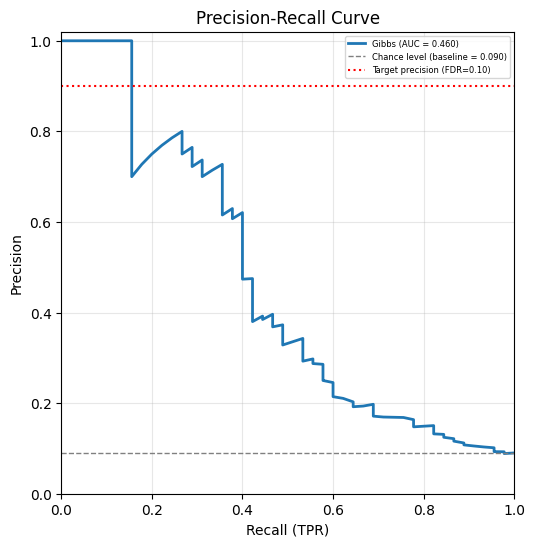

In [63]:
pip_vi = model_vi.rho
pip_gibbs = np.mean(gamma_samples, axis=0)

recision, recall, pr_auc = ev.plot_precision_recall_curve(sig_true, pip_vi, label="MFVI", target_fdr=0.1)
plt.show()

precision, recall, pr_auc = ev.plot_precision_recall_curve(sig_true, pip_gibbs, label="Gibbs", target_fdr=0.1)
plt.show()

In [64]:
sig_vi = model_vi.sig_vi(threshold=0.9)
sig_gibbs = pip_gibbs > 0.9
sig_true = (beta_true != 0)
theoretical_block_ids = np.repeat(np.arange(d // k), k)

TP, TN, FP, FN, n_blocks = ev.block_confusion_stats(sig_true, sig_vi, theoretical_block_ids)
confusion, stats = ev.compute_stats(TP, TN, FP, FN)

print("Stats per block - VI")
print("------------")
print(confusion)
print("------------")
print(stats)

TP, TN, FP, FN, n_blocks = ev.block_confusion_stats(sig_true, sig_gibbs, theoretical_block_ids)
confusion, stats = ev.compute_stats(TP, TN, FP, FN)

print("\nStats per block - Gibbs")
print("------------")
print(confusion)
print("------------")
print(stats)

Stats per block - VI
------------
                         Predicted: significant  Predicted: non-significant
Actual: significant                           8                          25
Actual: non-significant                       0                          17
------------
        Metric  Value
0    Precision  1.000
1       Recall  0.242
2  Specificity  1.000
3          NPV  0.405
4          FDR  0.000
5          FPR  0.000
6          FNR  0.758
7     Accuracy  0.500
8     F1-score  0.390
9          MCC  0.313

Stats per block - Gibbs
------------
                         Predicted: significant  Predicted: non-significant
Actual: significant                           7                          26
Actual: non-significant                       0                          17
------------
        Metric  Value
0    Precision  1.000
1       Recall  0.212
2  Specificity  1.000
3          NPV  0.395
4          FDR  0.000
5          FPR  0.000
6          FNR  0.788
7     Accuracy  0.480
8     

In [65]:
TP, TN, FP, FN = ev.confusion_stats(sig_true, sig_vi)
confusion, stats = ev.compute_stats(TP, TN, FP, FN)

print("Stats per column - VI")
print("------------")
print(confusion)
print("------------")
print(stats)

n_misattributed_blocks, n_misattributed_vars, pct_blocks, pct_cols = ev.count_misattributed_errors(
    sig_true, sig_vi, theoretical_block_ids
)

print("------------")
print(f"Misattributed blocks: {n_misattributed_blocks} ({pct_blocks:.1f}% of selected blocks)")
print(f"Misattributed variables: {n_misattributed_vars} ({pct_cols:.1f}% of selected columns)")


TP, TN, FP, FN = ev.confusion_stats(sig_true, sig_gibbs)
confusion, stats = ev.compute_stats(TP, TN, FP, FN)

print("\n\nStats per column - Gibbs")
print("------------")
print(confusion)
print("------------")
print(stats)

n_misattributed_blocks, n_misattributed_vars, pct_blocks, pct_cols = ev.count_misattributed_errors(
    sig_true, sig_gibbs, theoretical_block_ids
)

print("------------")
print(f"Misattributed blocks: {n_misattributed_blocks} ({pct_blocks:.1f}% of selected blocks)")
print(f"Misattributed variables: {n_misattributed_vars} ({pct_cols:.1f}% of selected columns)")

Stats per column - VI
------------
                         Predicted: significant  Predicted: non-significant
Actual: significant                           5                          40
Actual: non-significant                       3                         452
------------
        Metric  Value
0    Precision  0.625
1       Recall  0.111
2  Specificity  0.993
3          NPV  0.919
4          FDR  0.375
5          FPR  0.007
6          FNR  0.889
7     Accuracy  0.914
8     F1-score  0.189
9          MCC  0.238
------------
Misattributed blocks: 3 (37.5% of selected blocks)
Misattributed variables: 3 (37.5% of selected columns)


Stats per column - Gibbs
------------
                         Predicted: significant  Predicted: non-significant
Actual: significant                           7                          38
Actual: non-significant                       0                         455
------------
        Metric  Value
0    Precision  1.000
1       Recall  0.156
2  Specificity  

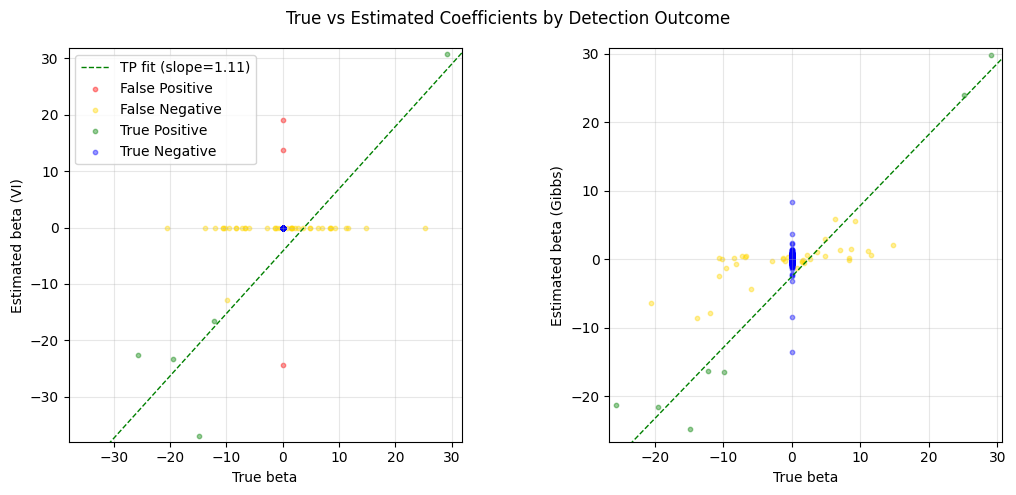

In [66]:
beta_vi = model_vi.m
beta_gibbs = np.mean(beta_samples, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ev.compare_effect_sizes(beta_true, beta_vi, sig_true, sig_vi, label = "VI", ax = axes[0])
ev.compare_effect_sizes(beta_true, beta_gibbs, sig_true, sig_gibbs, label = "Gibbs", ax = axes[1], legend = False)
fig.suptitle(f"True vs Estimated Coefficients by Detection Outcome")
plt.tight_layout()

plt.show()